<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Clustering Jerárquico y Dendrogramas
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Programación para Ciencia de Datos
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 10
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Science%20programming/10%20-%20Clustering/03_Clustering_Jerarquico_y_Dendrogramas.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. Clustering Aglomerativo: Un Enfoque *Bottom-Up* 🧠

El **clustering jerárquico aglomerativo** (*Agglomerative Hierarchical Clustering*, HAC) construye la partición de los datos con una estrategia opuesta a K-Means: en lugar de fijar $K$ y refinar centroides iterativamente, parte de que **cada observación es su propio clúster** (un total de $N$ clústeres singleton) y **fusiona iterativamente los dos clústeres más similares**, hasta que todos los puntos terminan en un único clúster.

Esta secuencia completa de fusiones —desde $N$ clústeres hasta $1$— se puede reconstruir y visualizar como un **dendrograma**: un árbol que representa la jerarquía completa de agrupamientos, en el cual la altura de cada fusión refleja qué tan "distintos" eran los dos clústeres fusionados.

A diferencia de K-Means, **no es necesario fijar $K$ de antemano** — se puede "cortar" el dendrograma a cualquier altura para obtener el número de clústeres deseado, e incluso explorar la estructura de los datos a múltiples niveles de granularidad simultáneamente.

Existen dos formas equivalentes de trabajar con clustering jerárquico en Python:

* Construir la **matriz de enlace** (*linkage matrix*) con **SciPy** (`scipy.cluster.hierarchy.linkage`) — da acceso directo a la estructura del árbol y permite graficar dendrogramas.
* Usar la clase `AgglomerativeClustering` de **scikit-learn** — con la interfaz estándar `.fit()` / `.fit_predict()`, más cómoda quien solo necesita las etiquetas finales.

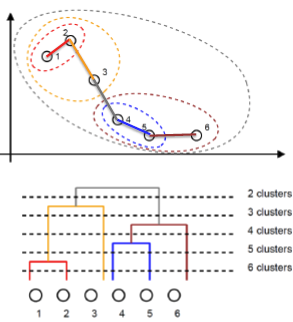

---
## Configuración del Entorno de Trabajo 🛠️

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys, urllib.request
import warnings
warnings.filterwarnings('ignore')

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (8.5, 4.5)
plt.rcParams['font.size'] = 10

def load_dataset(filename, module_folder="10 - Clustering"):
    local_path = os.path.join(os.getcwd(), "data", filename)
    if os.path.exists(local_path):
        return local_path

    parent_path = os.path.join(os.getcwd(), "..", module_folder, "data", filename)
    if os.path.exists(parent_path):
        return parent_path

    raw_url = f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Science%20programming/{module_folder.replace(' ', '%20')}/data/{filename}"
    os.makedirs("data", exist_ok=True)
    target_path = os.path.join("data", filename)
    if not os.path.exists(target_path):
        urllib.request.urlretrieve(raw_url, target_path)
    return target_path

# -- Carga robusta de functions/ (local o Colab) --
import pathlib as _pl, urllib.request as _req

_BASE_RAW = (
    "https://raw.githubusercontent.com/sazuniga06/"
    "Data-Science-Programming---USTA-Tunja-Repository/main/"
    "Data%20Science%20programming/10%20-%20Clustering/"
)

def _ensure_functions_pkg(check_file='dendrogram_util.py'):
    """Busca functions/ localmente; si no existe lo descarga desde GitHub."""
    for base in [_pl.Path(os.getcwd()), _pl.Path(os.getcwd()) / '..']:
        pkg = base / 'functions'
        if (pkg / check_file).exists():
            root = str(base.resolve())
            if root not in sys.path:
                sys.path.insert(0, root)
            return
    _pl.Path('functions').mkdir(exist_ok=True)
    for fname in ['__init__.py', 'dendrogram_util.py', 'clustering_metrics.py']:
        dest = _pl.Path('functions') / fname
        if not dest.exists():
            _req.urlretrieve(_BASE_RAW + f'functions/{fname}', dest)
    cwd = os.getcwd()
    if cwd not in sys.path:
        sys.path.insert(0, cwd)
    print('  ✅ functions/ descargado desde GitHub.')

_ensure_functions_pkg('dendrogram_util.py')
from functions.dendrogram_util import plot_dendrogram, plot_node

print("🚀 Entorno configurado exitosamente para el Módulo 10: Clustering.")

  ✅ functions/ descargado desde GitHub.
🚀 Entorno configurado exitosamente para el Módulo 10: Clustering.


---
## 2. La Matriz de Enlace (*Linkage Matrix*) con SciPy 🔗

```python
from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(X, metric='euclidean', method='ward')
```

`Z` es una matriz de tamaño $(N-1) \times 4$ que describe la secuencia completa de fusiones: la primera fila representa la primera fusión (la más "barata"), la última fila representa la fusión final (todos los puntos en un solo clúster). Cada fila contiene 4 valores:

| Columna | Significado |
|---|---|
| `id1` | Identificador del primer clúster/punto fusionado en este paso |
| `id2` | Identificador del segundo clúster/punto fusionado en este paso |
| `dist` | Distancia entre `id1` e `id2` antes de la fusión |
| `npoints` | Número de observaciones originales contenidas en el clúster resultante |

**Convención de identificadores:** un valor `id# < N` (con $N$ = número de observaciones originales) se refiere directamente a un **punto original** del dataset. Un valor `id# >= N` se refiere a un **clúster formado en un paso anterior** — ese clúster se reconstruye consultando la fila `id# - N` de la propia matriz `Z`. Esta es precisamente la lógica que implementa recursivamente la función auxiliar `get_node_leaves` del módulo `functions/dendrogram_util.py`.

---
## 3. Dataset de Trabajo: Dígitos Manuscritos (`load_digits`) 🔢

A diferencia del cuaderno anterior (clientes de un centro comercial en 2D), aquí trabajaremos con un dataset de **dígitos manuscritos** de 8×8 píxeles (`sklearn.datasets.load_digits`) — cada imagen se aplana en un vector de $8 \times 8 = 64$ características (intensidades de gris). Este dataset de mayor dimensionalidad permite ilustrar una de las grandes fortalezas del clustering jerárquico: no solo produce una partición final, sino que **expone sub-estructura y relaciones de similitud a múltiples niveles**, algo que resulta muy natural de inspeccionar visualmente con imágenes.

Forma de X: (1797, 64)  (N=1797 imágenes, 64 características)
Clases presentes: [0 1 2 3 4 5 6 7 8 9]


Text(0.5, 1.0, '0')

Text(0.5, 1.0, '1')

Text(0.5, 1.0, '2')

Text(0.5, 1.0, '3')

...

Text(0.5, 1.0, '6')

Text(0.5, 1.0, '7')

Text(0.5, 1.0, '8')

Text(0.5, 1.0, '9')

Text(0.5, 1.15, 'Primeras 10 Imágenes del Dataset `load_digits`')

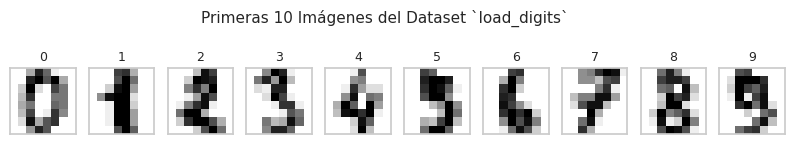

In [ ]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.images.reshape(-1, 8 * 8)   # aplanar cada imagen 8x8 en un vector de 64 características
y = digits.target

print(f"Forma de X: {X.shape}  (N={X.shape[0]} imágenes, {X.shape[1]} características)")
print(f"Clases presentes: {np.unique(y)}")

fig, axes = plt.subplots(1, 10, figsize=(10, 1.4), subplot_kw={'xticks': [], 'yticks': []})
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary', interpolation='nearest')
    ax.set_title(str(y[i]), fontsize=9)
plt.suptitle("Primeras 10 Imágenes del Dataset `load_digits`", fontsize=11, y=1.15)
plt.show()

In [ ]:
from scipy.cluster.hierarchy import linkage

Z = linkage(X, metric='euclidean', method='ward')

print(f"Forma de la matriz de enlace Z: {Z.shape}   (N-1 = {X.shape[0] - 1} fusiones)")
print("Primeras 5 fusiones (las más 'baratas', entre imágenes casi idénticas):")
print(pd.DataFrame(Z[:5], columns=['id1', 'id2', 'dist', 'npoints']))

Forma de la matriz de enlace Z: (1796, 4)   (N-1 = 1796 fusiones)
Primeras 5 fusiones (las más 'baratas', entre imágenes casi idénticas):
      id1     id2      dist  npoints
0  1585.0  1648.0  5.291503      2.0
1  1247.0  1250.0  7.549834      2.0
2   777.0  1237.0  7.937254      2.0
3  1076.0  1134.0  8.062258      2.0
4  1471.0  1485.0  8.185353      2.0


---
## 4. Graficando y Leyendo el Dendrograma 🌳

El módulo de utilidades `functions/dendrogram_util.py` de este repositorio expone tres funciones ya construidas para explorar dendrogramas:

* **`plot_dendrogram(Z=None, model=None, X=None, **kwargs)`**: grafica el dendrograma a partir de una matriz de enlace `Z` (o de un modelo `AgglomerativeClustering` ya ajustado). Soporta `truncate_mode='lastp'` junto con `p=<num_hojas_a_mostrar>` para truncar árboles grandes, y `n_clusters=<k>` para dibujar una línea horizontal de corte. Cada nodo de fusión se anota con un identificador **negativo** (`-1` = última fusión, `-2` = penúltima, etc.) que luego se puede consultar con `plot_node`.
* **`get_node_leaves(Z, idx, N)`**: recorre recursivamente el dendrograma desde la fila de fusión `idx`, recolectando los índices de todas las observaciones originales bajo esa rama.
* **`plot_node(Z, X, y, idx, maxn=15*15)`**: dado un identificador de nodo de fusión `idx` (puede ser negativo, siguiendo la convención de `plot_dendrogram`), muestra una cuadrícula con las imágenes de esa rama del árbol junto con una tabla de frecuencias de sus etiquetas reales — está construida específicamente para imágenes de dígitos de 8×8 (`reshape(8, 8)`), por lo que se usa junto con `load_digits()`.

Truncamos el dendrograma a las últimas 100 fusiones (`truncate_mode='lastp', p=100`) para que sea legible, y trazamos una línea de corte a la altura correspondiente a 10 clústeres.

Text(0.5, 1.0, 'Dendrograma (Truncado a 100 Hojas) — Método de Enlace: Ward')

Text(0.5, 0, 'Tamaño del clúster (o índice de la observación)')

Text(0, 0.5, 'Distancia de fusión')

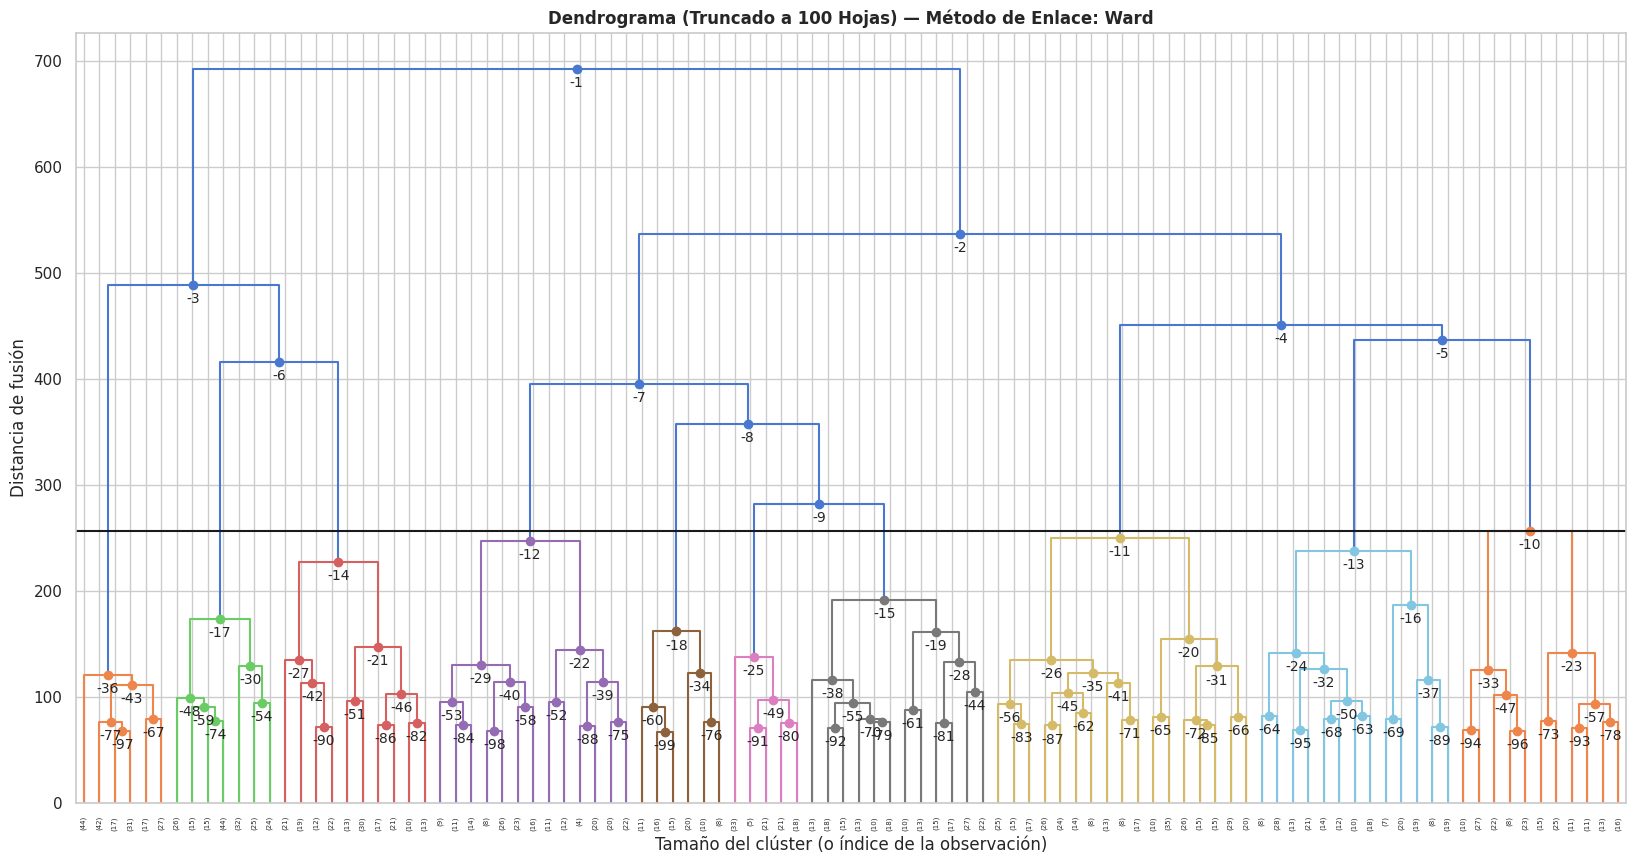

In [ ]:
fig, ax = plot_dendrogram(Z=Z, X=X, truncate_mode='lastp', p=100, n_clusters=10)
ax.set_title("Dendrograma (Truncado a 100 Hojas) — Método de Enlace: Ward", fontweight='bold')
ax.set_xlabel("Tamaño del clúster (o índice de la observación)")
ax.set_ylabel("Distancia de fusión")
plt.show()

### Inspeccionando Nodos Específicos con `plot_node`

Cada punto anotado en el dendrograma corresponde a una fusión concreta, identificable mediante un índice negativo. Inspeccionemos primero el **nodo `0`** — la primera fila de la matriz `Z`, es decir, **la primera fusión realizada por el algoritmo**: las dos observaciones (o clústeres) más parecidas de todo el dataset.

            1
Frequency:  2
Images in the cluster: 2 / 1797


Text(0.5, 1.05, 'Nodo 0: La Primera Fusión (Las Dos Imágenes Más Similares)')

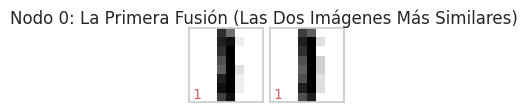

In [ ]:
plot_node(Z, X, y, 0)
plt.suptitle("Nodo 0: La Primera Fusión (Las Dos Imágenes Más Similares)", y=1.05)
plt.show()

Como es de esperar, el nodo `0` agrupa **dos imágenes prácticamente idénticas** del mismo dígito — es, por construcción, la fusión "más barata" (menor distancia) de todo el proceso.

Ahora inspeccionemos un nodo de fusión mucho más tardío — por ejemplo, el nodo `-14` (usando la convención de índices negativos de `plot_dendrogram`, donde `-1` es la última fusión realizada).

              4
Frequency:  178
Images in the cluster: 178 / 1797


Text(0.5, 1.02, 'Nodo -14: Una Fusión Tardía')

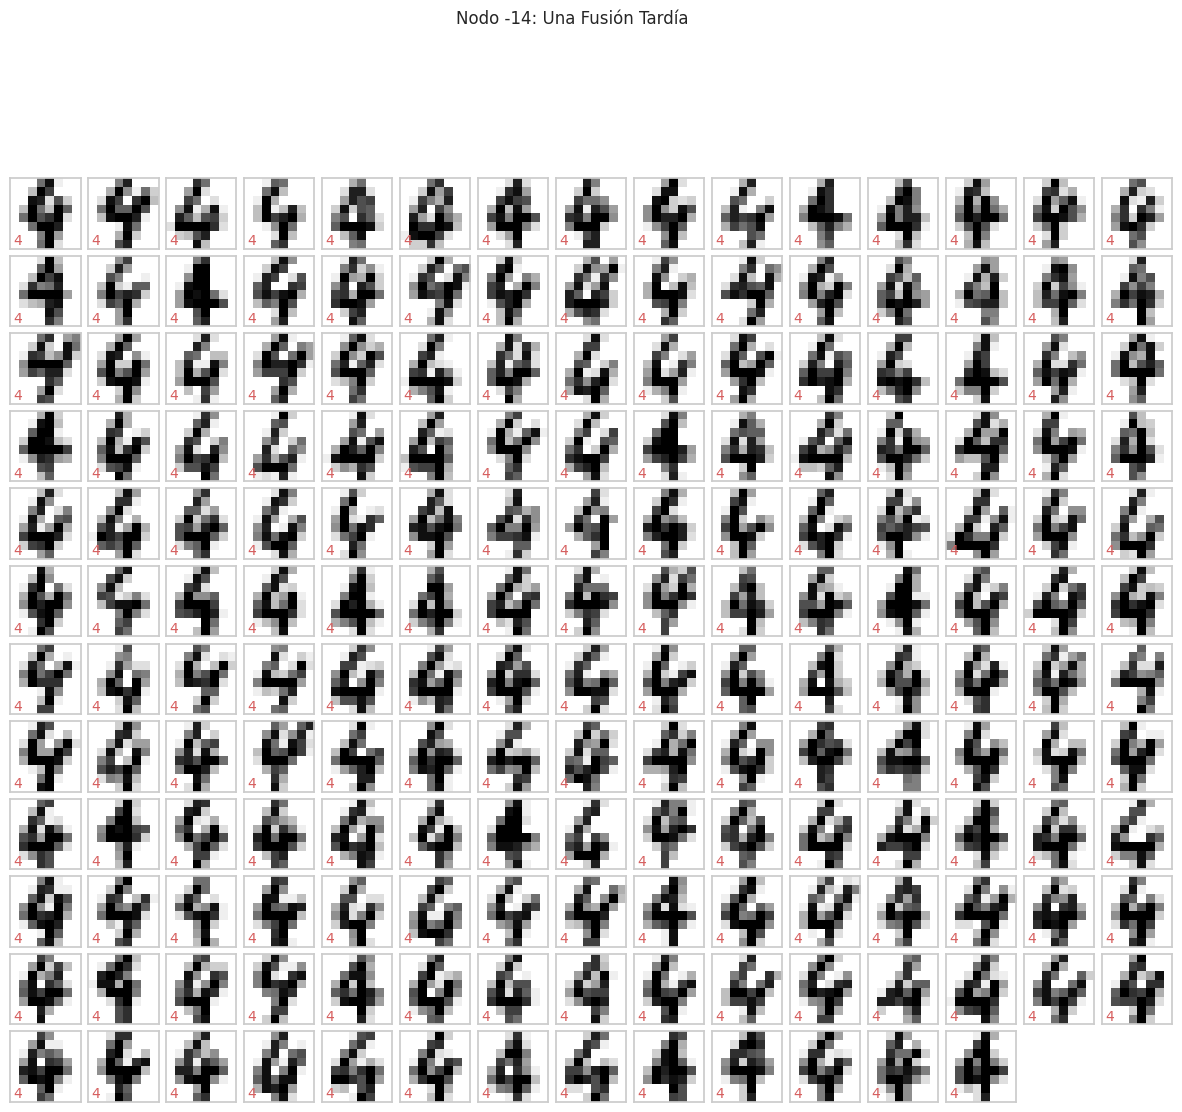

In [ ]:
plot_node(Z, X, y, -14)
plt.suptitle("Nodo -14: Una Fusión Tardía", y=1.02)
plt.show()

Este nodo tardío agrupa un clúster grande, mayoritariamente coherente (por ejemplo, dominado por un mismo dígito), pero **no perfectamente puro**. Si se inspeccionan sus dos sub-ramas inmediatas por separado (consultando `Z[idx, 0]` y `Z[idx, 1]` con `plot_node`), suele descubrirse que en realidad es la unión de dos **sub-estilos de escritura** del mismo dígito — por ejemplo, un "4" cerrado frente a un "4" abierto/con forma de U.

Este es precisamente uno de los grandes valores del clustering jerárquico frente a K-Means: **no solo entrega una partición final, sino que expone sub-estructura fina en distintos niveles del árbol** — convirtiéndolo también en una poderosa herramienta de **exploración y visualización de datos**, no únicamente en un método de clustering "final".

---
## 5. Métodos de Enlace (*Linkage Methods*) 📏

Dado un par de clústeres, ¿cómo decidimos "qué tan lejos" están entre sí (es decir, cuál par fusionar a continuación)? Esta decisión se llama **criterio de enlace** (*linkage criterion*), y distintos criterios producen dendrogramas — y particiones finales — sustancialmente distintos:

* **Complete (enlace completo / distancia intercluster máxima):** la mayor distancia por pares entre cualquier punto del clúster A y cualquier punto del clúster B.
* **Single (enlace simple / distancia intercluster mínima):** la menor de esas distancias por pares.
* **Average / Median (promedio / mediana):** el promedio (o la mediana) de todas las distancias por pares entre los dos clústeres.
* **Centroid (centroide):** la distancia entre los puntos centroide (promedio) de los dos clústeres.
* **Ward (mínimo incremento de varianza):** fusiona el par de clústeres que produce el **menor incremento en la varianza total intra-cluster**. Es el valor por defecto en scikit-learn y, en general, la elección más estable.

<div align="center">
  <img src="images/hac_linkage_methods.PNG" width="600" alt="Métodos de Enlace en Clustering Jerárquico" style="border-radius:8px; box-shadow: 0 4px 6px rgba(0,0,0,0.15); margin: 10px 0;"/>
  <p style="font-size: 0.85em; color: #64748b;">
    <i>Figura: Cada método de enlace mide la distancia entre clústeres de una manera distinta — de allí que produzcan dendrogramas y particiones diferentes sobre los mismos datos.</i>
  </p>
</div>

### Notas Comparativas

* **Single** tiende a producir fusiones pequeñas y graduales (un efecto de **"encadenamiento"** o *chaining*), y no funciona bien cuando los puntos están todos relativamente cerca entre sí — termina fusionando puntos individuales en un clúster cada vez más grande, en lugar de encontrar grupos bien separados.
* **Complete** tiende a producir saltos de distancia más grandes que single/average, generando clústeres más compactos y balanceados.
* **Centroid** puede sufrir **inversiones**: la altura del dendrograma puede *disminuir* en una fusión posterior, porque el centroide de un clúster se desplaza tras cada fusión y puede terminar más cerca de otro clúster de lo que estaba antes — esto dificulta la lectura limpia del dendrograma (las alturas dejan de ser monótonamente crecientes).
* **Ward** es, en general, la opción por defecto más estable y la más utilizada en la práctica.

{'icoord': [[285.0, 285.0, 295.0, 295.0],
  [275.0, 275.0, 290.0, 290.0],
  [265.0, 265.0, 282.5, 282.5],
  [255.0, 255.0, 273.75, 273.75],
  [245.0, 245.0, 264.375, 264.375],
  [235.0, 235.0, 254.6875, 254.6875],
  [225.0, 225.0, 244.84375, 244.84375],
  [215.0, 215.0, 234.921875, 234.921875],
  [205.0, 205.0, 224.9609375, 224.9609375],
  [195.0, 195.0, 214.98046875, 214.98046875],
  [185.0, 185.0, 204.990234375, 204.990234375],
  [175.0, 175.0, 194.9951171875, 194.9951171875],
  [165.0, 165.0, 184.99755859375, 184.99755859375],
  [155.0, 155.0, 174.998779296875, 174.998779296875],
  [145.0, 145.0, 164.9993896484375, 164.9993896484375],
  [135.0, 135.0, 154.99969482421875, 154.99969482421875],
  [125.0, 125.0, 144.99984741210938, 144.99984741210938],
  [115.0, 115.0, 134.9999237060547, 134.9999237060547],
  [105.0, 105.0, 124.99996185302734, 124.99996185302734],
  [95.0, 95.0, 114.99998092651367, 114.99998092651367],
  [85.0, 85.0, 104.99999046325684, 104.99999046325684],
  [75.0, 75.

Text(0.5, 1.0, "Método de Enlace: 'single'")

Text(0, 0.5, 'Distancia de fusión')

{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [5.0, 5.0, 20.0, 20.0],
  [45.0, 45.0, 55.0, 55.0],
  [35.0, 35.0, 50.0, 50.0],
  [12.5, 12.5, 42.5, 42.5],
  [65.0, 65.0, 75.0, 75.0],
  [85.0, 85.0, 95.0, 95.0],
  [115.0, 115.0, 125.0, 125.0],
  [105.0, 105.0, 120.0, 120.0],
  [90.0, 90.0, 112.5, 112.5],
  [70.0, 70.0, 101.25, 101.25],
  [27.5, 27.5, 85.625, 85.625],
  [145.0, 145.0, 155.0, 155.0],
  [135.0, 135.0, 150.0, 150.0],
  [185.0, 185.0, 195.0, 195.0],
  [205.0, 205.0, 215.0, 215.0],
  [190.0, 190.0, 210.0, 210.0],
  [175.0, 175.0, 200.0, 200.0],
  [165.0, 165.0, 187.5, 187.5],
  [142.5, 142.5, 176.25, 176.25],
  [235.0, 235.0, 245.0, 245.0],
  [255.0, 255.0, 265.0, 265.0],
  [240.0, 240.0, 260.0, 260.0],
  [225.0, 225.0, 250.0, 250.0],
  [285.0, 285.0, 295.0, 295.0],
  [275.0, 275.0, 290.0, 290.0],
  [237.5, 237.5, 282.5, 282.5],
  [159.375, 159.375, 260.0, 260.0],
  [56.5625, 56.5625, 209.6875, 209.6875]],
 'dcoord': [[0.0,
   np.float64(56.929781309961136),
   np.float64(56.9297813

Text(0.5, 1.0, "Método de Enlace: 'complete'")

...

Text(0.5, 1.0, "Método de Enlace: 'average'")

Text(0, 0.5, 'Distancia de fusión')

{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [35.0, 35.0, 45.0, 45.0],
  [55.0, 55.0, 65.0, 65.0],
  [40.0, 40.0, 60.0, 60.0],
  [20.0, 20.0, 50.0, 50.0],
  [5.0, 5.0, 35.0, 35.0],
  [75.0, 75.0, 85.0, 85.0],
  [95.0, 95.0, 105.0, 105.0],
  [80.0, 80.0, 100.0, 100.0],
  [115.0, 115.0, 125.0, 125.0],
  [135.0, 135.0, 145.0, 145.0],
  [175.0, 175.0, 185.0, 185.0],
  [165.0, 165.0, 180.0, 180.0],
  [155.0, 155.0, 172.5, 172.5],
  [140.0, 140.0, 163.75, 163.75],
  [120.0, 120.0, 151.875, 151.875],
  [90.0, 90.0, 135.9375, 135.9375],
  [195.0, 195.0, 205.0, 205.0],
  [215.0, 215.0, 225.0, 225.0],
  [200.0, 200.0, 220.0, 220.0],
  [235.0, 235.0, 245.0, 245.0],
  [255.0, 255.0, 265.0, 265.0],
  [240.0, 240.0, 260.0, 260.0],
  [285.0, 285.0, 295.0, 295.0],
  [275.0, 275.0, 290.0, 290.0],
  [250.0, 250.0, 282.5, 282.5],
  [210.0, 210.0, 266.25, 266.25],
  [112.96875, 112.96875, 238.125, 238.125],
  [20.0, 20.0, 175.546875, 175.546875]],
 'dcoord': [[0.0,
   np.float64(173.62426784769744),
   np.floa

Text(0.5, 1.0, "Método de Enlace: 'ward'")

Text(0, 0.5, 'Distancia de fusión')

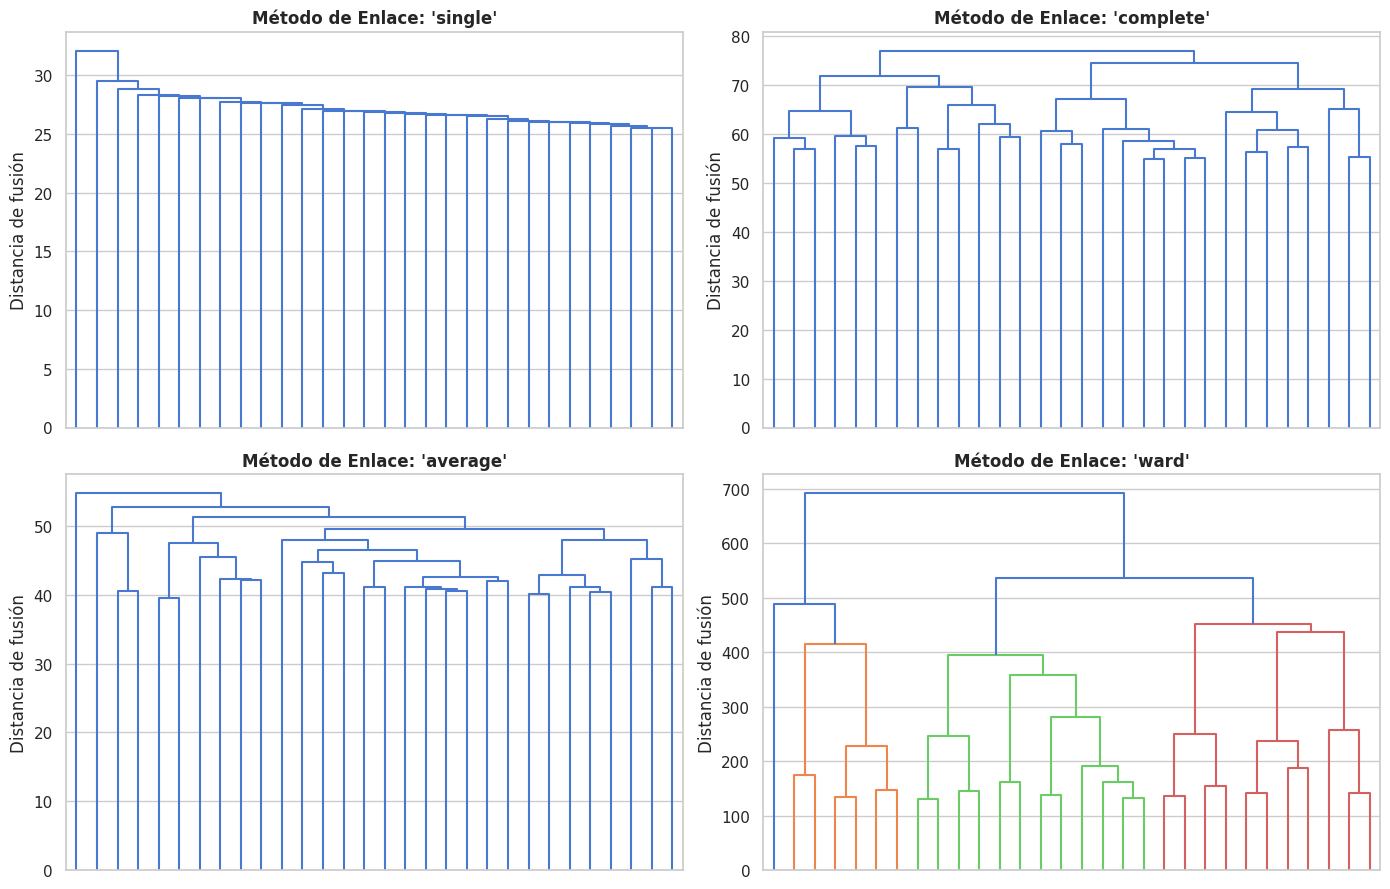

In [ ]:
from scipy.cluster.hierarchy import dendrogram

methods = ['single', 'complete', 'average', 'ward']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, method in zip(axes.flat, methods):
    Z_method = linkage(X, metric='euclidean', method=method)
    dendrogram(Z_method, truncate_mode='lastp', p=30, ax=ax, no_labels=True)
    ax.set_title(f"Método de Enlace: '{method}'", fontweight='bold')
    ax.set_ylabel("Distancia de fusión")

plt.tight_layout()
plt.show()

Nótese cómo **`single`** genera un dendrograma con muchas fusiones a alturas muy bajas y pocos saltos grandes (el efecto de encadenamiento descrito arriba), mientras que **`ward`** y **`complete`** producen estructuras más balanceadas, con grupos que se fusionan a alturas progresivamente mayores y más claramente diferenciadas — de allí que **`ward`** sea preferible como punto de partida por defecto en la mayoría de aplicaciones.

---
## 6. `AgglomerativeClustering` de Scikit-Learn ⚡

Cuando solo se necesitan las etiquetas finales de clúster (sin explorar el dendrograma completo), la clase `sklearn.cluster.AgglomerativeClustering` ofrece la interfaz estándar `.fit()` / `.fit_predict()`:

```python
from sklearn.cluster import AgglomerativeClustering
aggl_model = AgglomerativeClustering(n_clusters=10, distance_threshold=None,
                                      metric='euclidean', linkage='ward')
y_predict = aggl_model.fit_predict(X)
```

Se puede especificar **o bien** `n_clusters` (número fijo de clústeres deseado) **o bien** `distance_threshold` (cortar el dendrograma a una altura dada, dejando que el número de clústeres emerja naturalmente) — **pero no ambos a la vez**: al usar `distance_threshold` es obligatorio pasar `n_clusters=None`.

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

aggl_model = AgglomerativeClustering(n_clusters=10, metric='euclidean', linkage='ward')
y_predict = aggl_model.fit_predict(X)

print(f"Número de clústeres formados: {len(np.unique(y_predict))}")
print(f"Adjusted Rand Index frente a las etiquetas reales: {adjusted_rand_score(y, y_predict):.3f}")

Número de clústeres formados: 10
Adjusted Rand Index frente a las etiquetas reales: 0.794


El **Adjusted Rand Index** (ARI) compara la partición encontrada por el algoritmo contra las etiquetas reales de los dígitos (que en un escenario real de clustering no estarían disponibles) — sirve aquí únicamente como validación pedagógica de que el clustering jerárquico, sin ver ninguna etiqueta, logra recuperar una estructura razonablemente alineada con los 10 dígitos verdaderos. Este tipo de métrica se estudiará con más detalle en el cuaderno 05.

---
## 7. Puntos Clave ⚠️

* **Costo computacional elevado:** $O(n^3)$ en tiempo y $O(n^2)$ en espacio, porque cada una de las $n-1$ fusiones requiere actualizar una matriz de proximidad de tamaño $O(n^2)$. Esto hace que el clustering jerárquico **no sea práctico para datasets muy grandes** (a diferencia de K-Means, que escala mucho mejor).
* **Múltiples criterios de enlace:** la elección del método de enlace determina qué tipo de formas de clúster se pueden identificar — Ward para clústeres compactos y balanceados, single para detectar estructuras alargadas (a costa del efecto de encadenamiento).
* **Sin concepto de ruido:** al igual que K-Means, **todo punto termina asignado a algún clúster** ("ningún punto se queda atrás") — a diferencia de DBSCAN (cuaderno 04), no existe la noción de punto atípico o de ruido.
* **No requiere fijar $K$ de antemano:** se puede decidir el número de clústeres *después* de construir el árbol completo, simplemente cortando el dendrograma a la altura deseada — una ventaja importante frente a K-Means quien exige el valor de $K$ como entrada.

---
##### 🛠️ Práctica 1: Comparando Métodos de Enlace con el Índice de Rand Ajustado

**Objetivo:** Cuantificar, más allá de la inspección visual del apartado 5, cuál método de enlace (`single`, `complete`, `average`, `ward`) produce una partición de 10 clústeres más parecida a las etiquetas reales de dígitos.

**Instrucciones:**
1. Para cada método en `['single', 'complete', 'average', 'ward']`, ajusta un `AgglomerativeClustering(n_clusters=10, linkage=<método>)` sobre `X`.
2. Calcula el `adjusted_rand_score(y, y_predict)` para cada método.
3. Organiza los resultados en un `pd.DataFrame` ordenado de mayor a menor ARI.
4. Responde: ¿el método con mejor ARI coincide con lo que la teoría de la sección 5 sugeriría como el más estable? ¿Por qué `single` suele quedar rezagado en este tipo de comparación?

In [ ]:
# =========================================================================
# TU SOLUCIÓN: Práctica 1 - Comparación de Métodos de Enlace con ARI
# =========================================================================

# 1-2. Ajustar AgglomerativeClustering para cada método y calcular el ARI
# resultados = []
# for method in ['single', 'complete', 'average', 'ward']:
#     modelo = AgglomerativeClustering(n_clusters=10, linkage=method)
#     y_pred = modelo.fit_predict(X)
#     ari = adjusted_rand_score(y, y_pred)
#     resultados.append({'linkage': method, 'ARI': ari})

# 3. DataFrame ordenado
# df_resultados = pd.DataFrame(resultados).sort_values('ARI', ascending=False)
# df_resultados

# 4. (Responde en una celda markdown)


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
resultados = []
for method in ['single', 'complete', 'average', 'ward']:
    modelo = AgglomerativeClustering(n_clusters=10, linkage=method)
    y_pred = modelo.fit_predict(X)
    ari = adjusted_rand_score(y, y_pred)
    resultados.append({'linkage': method, 'ARI': round(ari, 4)})

df_resultados = pd.DataFrame(resultados).sort_values('ARI', ascending=False).reset_index(drop=True)
print(df_resultados)
```

**Interpretación esperada:** `ward` (y con frecuencia `average`) suelen obtener el mayor ARI, mientras que `single` típicamente obtiene el peor resultado por un margen amplio. Esto es consistente con la teoría de la sección 5: el efecto de **encadenamiento** de `single` tiende a producir un clúster gigante que absorbe casi todos los puntos, más un puñado de clústeres diminutos de 1-2 observaciones — una partición muy alejada de los 10 grupos balanceados que definen los dígitos reales. `ward`, al minimizar el incremento de varianza en cada fusión, favorece clústeres compactos y de tamaño más equilibrado, lo cual encaja mucho mejor con la estructura real de este dataset.
</details>

---
### 8. Resumen y Conclusiones del Cuaderno 03 📌

1. **Enfoque Bottom-Up:** el clustering jerárquico aglomerativo parte de $N$ clústeres singleton y fusiona iterativamente los dos más similares, construyendo un dendrograma que representa la jerarquía completa de agrupamientos.
2. **La Matriz de Enlace es la Estructura Central:** `Z = linkage(X, method=...)` codifica toda la secuencia de fusiones; el módulo `functions/dendrogram_util.py` permite visualizarla e inspeccionar nodos específicos (`plot_dendrogram`, `plot_node`).
3. **El Método de Enlace Cambia Todo:** `single` produce encadenamiento, `complete` clústeres compactos, `centroid` puede generar inversiones, y `ward` (el más usado por defecto) minimiza el incremento de varianza intra-cluster.
4. **No Requiere Fijar $K$ de Antemano:** el número de clústeres se decide *después* de construir el árbol, cortando el dendrograma a la altura deseada — a costa de un costo computacional $O(n^3)$ que limita su uso a datasets de tamaño moderado.
5. **Próximos Pasos:** **DBSCAN** (cuaderno 04) introduce un enfoque completamente distinto, basado en densidad, capaz de identificar formas de clúster arbitrarias y de detectar explícitamente puntos de ruido — algo que ni K-Means ni el clustering jerárquico pueden hacer.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Programación para Ciencia de Datos</i>
  </p>
</div>